# EMachine Analysis Notebook

This notebook contains comprehensive analysis of Epsilon Machines (EMachines) for various stochastic processes and quantum state analysis.

## Import Libraries and Setup

First, let's import all necessary libraries and set up the environment.

In [ ]:
import numpy as np
from emachine_v2 import bird
from emachine_v2 import EMachine as EM
from emachine_v2 import PhasedEMachine as PEM
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set up matplotlib for better plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = [10, 6]

## Reloading the emachine module (hot-reload)


- Purpose: Ensure the latest changes to `emachine.py` are used without restarting the kernel.
- What it does: Removes cached `emachine` modules from `sys.modules`, invalidates import caches, and reloads.
- When to use: Run this after editing `emachine.py` to test changes immediately.
- Output: Prints which modules were cleared and confirms successful reload.


In [545]:
import sys
import importlib
import traceback

# Check if 'emachine_v2' module is cached, remove it from sys.modules and re-import fresh

module_name = 'emachine_v2'
cached_keys = [k for k in sys.modules.keys() if k == module_name or k.startswith(module_name + '.')]

if cached_keys:
    print(f"Found cached emachine_v2 modules ({len(cached_keys)}):")
    for k in cached_keys:
        print(f"  - {k}")
    for k in cached_keys:
        try:
            del sys.modules[k]
        except KeyError:
            pass
    importlib.invalidate_caches()
    print("Deleted cached emachine_v2 entries from sys.modules and invalidated import caches.")
else:
    print("No cached 'emachine_v2' module found in sys.modules.")

# Re-import the module and update all references
try:
    emachine_module = importlib.import_module(module_name)
    # if the module was previously loaded elsewhere, force reload to be safe
    emachine_module = importlib.reload(emachine_module)
    
    # Update ALL imported names from the reloaded module
    EM = getattr(emachine_module, 'EMachine')
    w_bird = getattr(emachine_module, 'w_bird')
    PEM = getattr(emachine_module, 'PhasedEMachine')
    
    print(f"Successfully reloaded '{module_name}'")
    print(f"  ✓ EM (EMachine class)")
    print(f"  ✓ w_bird (function)")
    print(f"  ✓ PEM (PhasedEMachine class)")
    print("\nAll references updated to use latest module version.")
except Exception:
    print(f"Failed to import/reload '{module_name}':")
    traceback.print_exc()


Found cached emachine_v2 modules (1):
  - emachine_v2
Deleted cached emachine_v2 entries from sys.modules and invalidated import caches.
Successfully reloaded 'emachine_v2'
  ✓ EM (EMachine class)
  ✓ w_bird (function)
  ✓ PEM (PhasedEMachine class)

All references updated to use latest module version.


## 1. Even Process Analysis

The even process is a fundamental example where we analyze a binary stochastic process with parameter P.

In [546]:
# Define the even process transition tensor
def T_even_process(p):
    """
    Transition tensor for even process with parameter p
    """
    return np.array([[[p, 0],
                      [0, 0]],
                     [[0, 1 - p],
                      [1, 0]]])**(1/2)

# Create EMachine factory function
em_even = lambda p: EM(T_even_process(p))

# Test with specific parameter
P = 0.4
T_test = T_even_process(P)
em_test = EM(T_test)

print(f"Even process with P = {P}")
print(f"Transition tensor shape: {T_test.shape}")
print(f"EMachine dimension: {em_test.dim}")

# Observable matrix for analysis
O = np.array([[1, 0], [0, -1]])
print(f"\nObservable O:")
print(O)

Even process with P = 0.4
Transition tensor shape: (2, 2, 2)
EMachine dimension: 2

Observable O:
[[ 1  0]
 [ 0 -1]]


### Analyze Observable Decay (helper function)


- Purpose: Fit the decay of an observable vs. iteration `n`.
- Inputs: parameter `p`, `max_n` (default 100), and observable `O` from earlier.
- Outputs:
  - Two plots (observable over `n`, and log-absolute with linear fit).
  - Printed slope of the exponential decay where `slope = d/dn [log|observable|]`.
- Notes: Handles non-finite values robustly and shows a fitted guide line if possible.


In [547]:
# Updated function that will work with the reloaded EMachine
def analyze_observable_decay(p, max_n=100):
    """
    Analyze how observables decay with time steps n.
    Returns the fitted slope of log(|observable|) vs n, or np.nan if fit not possible.
    """
    em_p = EM(T_even_process(p))  # Create fresh instance with reloaded class
    n = np.arange(1, max_n + 1)
    
    # Check if observable method exists
    if not hasattr(em_p, 'observable'):
        print(f"Error: EMachine class doesn't have 'observable' method")
        print(f"Available methods: {[m for m in dir(em_p) if not m.startswith('_')]}")
        return np.nan
    
    # Compute observables for each n
    obs = np.array([em_p.observable(O, l) for l in n])
    y = np.log(np.abs(obs))
    mask = np.isfinite(y)
    
    slope = np.nan
    intercept = np.nan
    if mask.sum() >= 2:
        slope, intercept = np.polyfit(n[mask], y[mask], 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(n, np.real(obs), 'b-', label='Real(Observable)')
    if np.any(np.imag(obs) != 0):
        plt.plot(n, np.imag(obs), 'r--', label='Imag(Observable)')
    plt.xlabel('n')
    plt.ylabel('Observable value')
    plt.title(f'Observable vs n (P={p})')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(n[mask], y[mask], 'ro', label='log(|observable|)', markersize=3)
    if mask.sum() >= 2:
        plt.plot(n, slope * n + intercept, 'g--', label=f'Linear fit (slope={slope:.6f})')
    plt.xlabel('n')
    plt.ylabel('log(|Observable|)')
    plt.title(f'Log Observable Decay (P={p})')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    if mask.sum() >= 2:
        print(f'Decay slope = {slope:.6f}')
        return slope
    else:
        print('Not enough finite points to fit')
        return np.nan

# Update the em_even factory function to use reloaded class
em_even = lambda p: EM(T_even_process(p))

print("Functions updated to use reloaded EMachine class")

Functions updated to use reloaded EMachine class


### Parameter Sweep (observable O)


- Purpose: Scan `P∈(0,1)` and estimate decay slopes quickly using short `n` range.
- Method: Compute correlation `corr(l)` for `l=1..9`, fit `log|corr|` vs `n`.
- Output: Line plot of decay factor per step `exp(slope)` vs `P`, with the strongest decay annotated.
- Caveat: Short `n` window gives a rough slope; use longer `n` for precision.


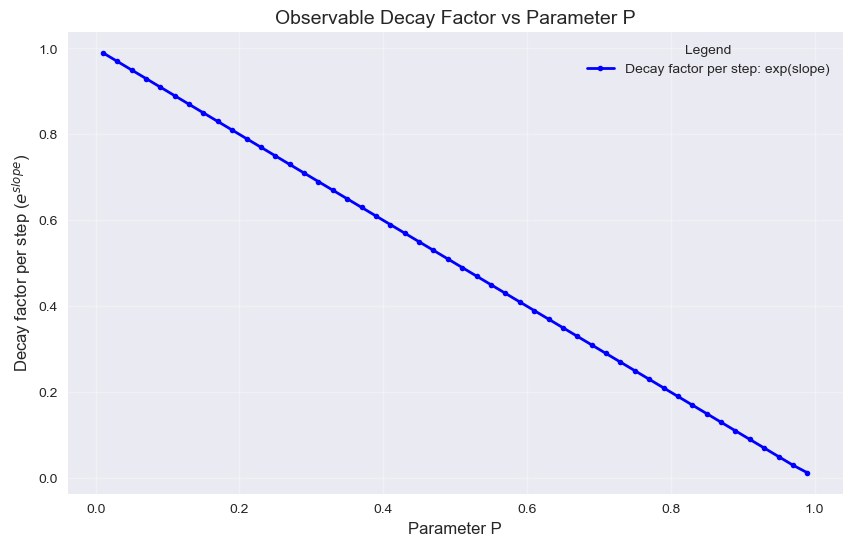

In [548]:
# Parameter sweep analysis - how decay slope changes with P
def parameter_sweep_analysis():
    """
    Analyze how the observable decay slope varies with parameter P
    """
    p_values = np.linspace(0.01, 0.99, 50)  # Avoid exact 0 and 1
    n = np.arange(1, 10)
    
    slopes = []
    for p in p_values:
        try:
            em_p = em_even(p)
            obs = np.array([em_p.correlation(O, l) for l in n])
            y = np.log(np.abs(obs))
            mask = np.isfinite(y)
            if mask.sum() >= 2:
                slope, _ = np.polyfit(n[mask], y[mask], 1)
            else:
                slope = np.nan
        except:
            slope = np.nan
        slopes.append(slope)
    
    slopes = np.array(slopes)
    
    plt.figure(figsize=(10, 6))
    plt.plot(p_values, np.exp(slopes), 'bo-', linewidth=2, markersize=4, label='Decay factor per step: exp(slope)')
    plt.xlabel('Parameter P', fontsize=12)
    plt.ylabel(r'Decay factor per step ($e^{slope}$)', fontsize=12)
    plt.title('Observable Decay Factor vs Parameter P', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(title='Legend')

    # annotate the most negative slope (largest decay)
    if np.all(np.isnan(slopes)) is False:
        try:
            idx_min = np.nanargmin(slopes)
            plt.scatter([p_values[idx_min]], [np.exp(slopes[idx_min])], color='red', zorder=5)
            plt.annotate(f'P={p_values[idx_min]:.3f}\nslope={slopes[idx_min]:.3f}',
                         xy=(p_values[idx_min], np.exp(slopes[idx_min])),
                         xytext=(10, -30), textcoords='offset points',
                         arrowprops=dict(arrowstyle='->', color='red'),
                         fontsize=10, color='red')
        except Exception:
            pass

    plt.show()
    
    return p_values, slopes

p_values, slopes = parameter_sweep_analysis()


### Parameter Sweep (observable O2)


- Purpose: Repeat sweep using `O2 = [[0,1],[1,0]]` to contrast decay vs `O`.
- Output: Plot of `(e^{slope})^2` vs `P` capturing a squared-decay interpretation.
- Tip: Compare positions of minima/maxima between the two sweeps to identify sensitivity to observable choice.


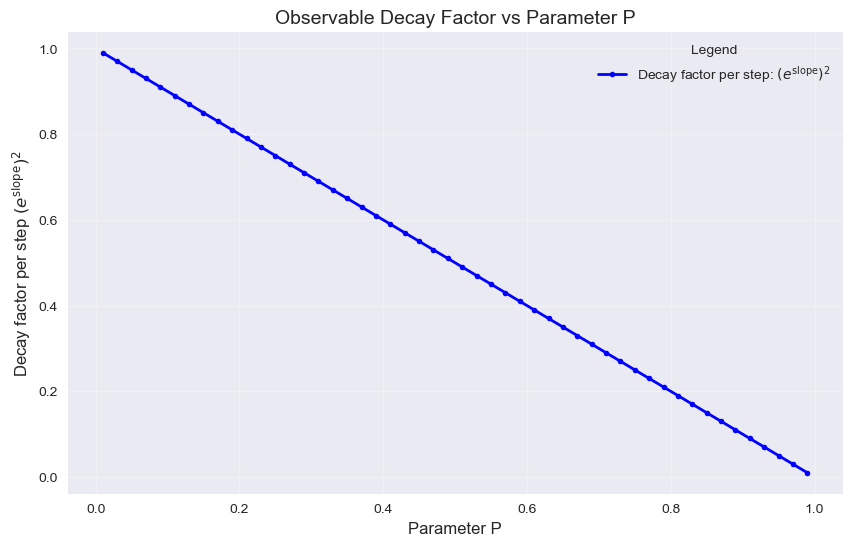

In [549]:
# Parameter sweep analysis - how decay slope changes with P
O2 = np.array([[0, 1],[1, 0]])
def parameter_sweep_analysis_2():
    """
    Analyze how the observable decay slope varies with parameter P
    """
    p_values = np.linspace(0.01, 0.99, 50)  # Avoid exact 0 and 1
    n = np.arange(1, 10)
    
    slopes = []
    for p in p_values:
        try:
            em_p = em_even(p)
            obs = np.array([em_p.correlation(O2, l) for l in n])
            y = np.log(np.abs(obs))
            mask = np.isfinite(y)
            if mask.sum() >= 2:
                slope, _ = np.polyfit(n[mask], y[mask], 1)
            else:
                slope = np.nan
        except:
            slope = np.nan
        slopes.append(slope)
    
    slopes = np.array(slopes)
    
    plt.figure(figsize=(10, 6))
    plt.plot(p_values, np.exp(slopes)**2, 'bo-', linewidth=2, markersize=4, label=r'Decay factor per step: $(e^{\text{slope}})^2$')
    plt.xlabel('Parameter P', fontsize=12)
    plt.ylabel(r'Decay factor per step $(e^{\text{slope}})^2$', fontsize=12)
    plt.title('Observable Decay Factor vs Parameter P', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(title='Legend')

    # annotate the most negative slope (largest decay)
    if np.all(np.isnan(slopes)) is False:
        try:
            idx_min = np.nanargmin(slopes)
            plt.scatter([p_values[idx_min]], [np.exp(slopes[idx_min])], color='red', zorder=5)
            plt.annotate(f'P={p_values[idx_min]:.3f}\nslope={slopes[idx_min]:.3f}',
                         xy=(p_values[idx_min], np.exp(slopes[idx_min])),
                         xytext=(10, -30), textcoords='offset points',
                         arrowprops=dict(arrowstyle='->', color='red'),
                         fontsize=10, color='red')
        except Exception:
            pass

    plt.show()
    
    return p_values, slopes

p_values, slopes = parameter_sweep_analysis_2()

### Correlation comparison: base vs phase-modified

The cell below computes the correlation observable for the base even-process EMachine (`em_even(P)`) and the phase-modified EMachine (`pem_even(P, φ)`) at a single representative phase (φ = π/2).

- We compute `corr(n) = em.correlation(O, n)` for n=1..20 for both machines.
- The plots show the real part and the absolute value of the correlation to highlight any phase-induced oscillations and changes in decay behaviour.
- Use these plots to visually compare decay rates and phase effects before running a multi-phase sweep.

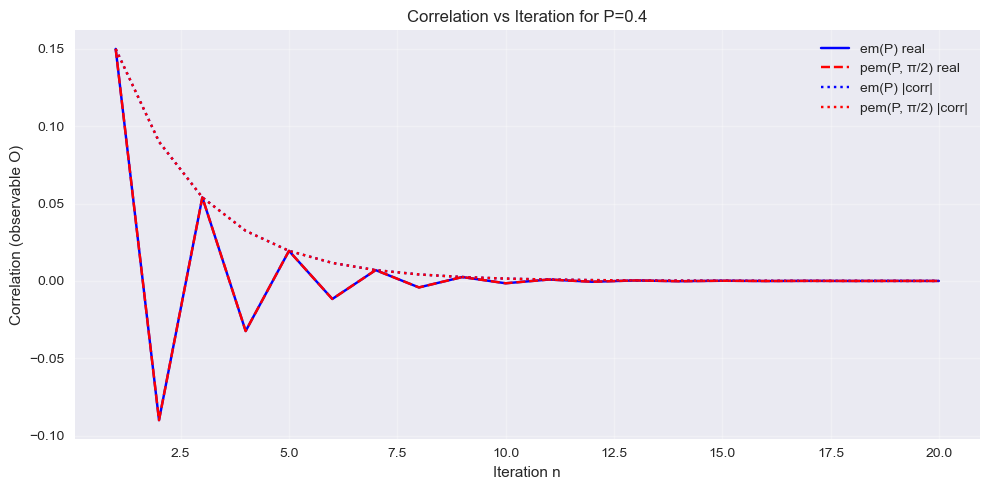

In [550]:
# Plot correlation function for em(P) and pem(P, pi/2)
# Uses existing: T_even_process, em_even, EM, O (observable), np, plt

# fallback for P if not defined earlier in the notebook
try:
    P
except NameError:
    P = 0.4

PHASE = np.pi/2
def pem_even(p, phi):
    """
    Phase-modified even-process EMachine:
    multiply the second symbol's transition slice by exp(i*phi).
    """
    return PEM(T_even_process(p).astype(complex), np.array([0, phi]))

n = np.arange(1,21)

em_base = em_even(P)
em_phase = pem_even(P, PHASE)
corr_base = np.array([em_base.correlation(O, k) for k in n])
corr_phase = np.array([em_phase.correlation(O, k) for k in n])

plt.figure(figsize=(10, 5))
plt.plot(n, np.real(corr_base), 'b-', label='em(P) real')
plt.plot(n, np.real(corr_phase), 'r--', label='pem(P, π/2) real')
plt.plot(n, np.abs(corr_base), 'b:', label='em(P) |corr|')
plt.plot(n, np.abs(corr_phase), 'r:', label='pem(P, π/2) |corr|')

plt.xlabel('Iteration n')
plt.ylabel('Correlation (observable O)')
plt.title(f'Correlation vs Iteration for P={P}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Multi-phase sweep: log(|correlation|)

This cell performs a sweep over several phase values φ in [0, π/2) and plots log(|corr(n)|) vs iteration n.

- Each colored line is a different φ; compare the slopes and offsets to assess whether phase alters decay rates or only introduces oscillatory components.
- We clip tiny magnitudes to avoid taking the logarithm of zero. Phases that produce numerical issues are skipped.

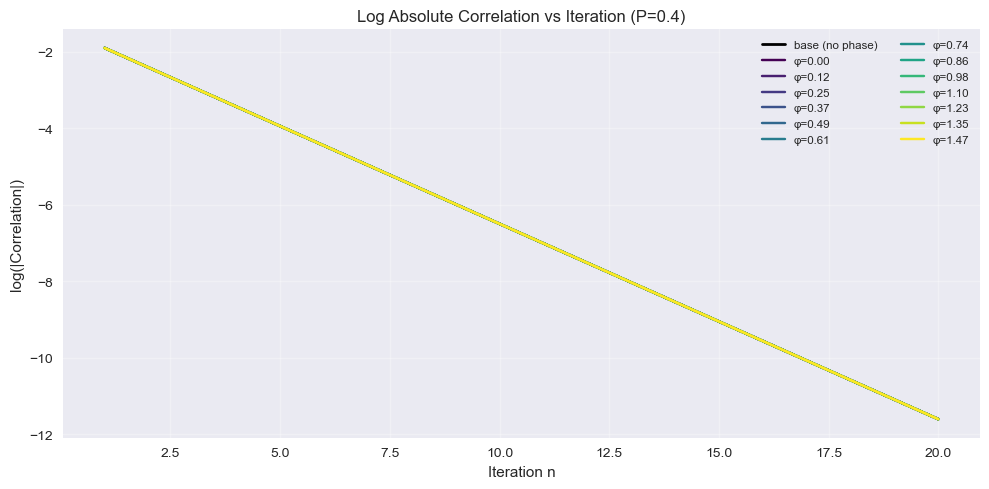

In [551]:
# Multi-phase log(|correlation|) plot for phases in [0, pi/2]
phases = np.linspace(0, np.pi/2-0.1, 13)  # more phase samples
plt.figure(figsize=(10, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(phases)))

# baseline (no phase) using existing em_base if available
try:
    corr_base_vals = np.array([pem_even(P, 0).correlation(O, k) for k in n])
    y_base = np.log(np.clip(np.abs(corr_base_vals), 1e-300, None))
    plt.plot(n, y_base, color='k', linewidth=2, label='base (no phase)')
except Exception:
    print('Error')
    pass

for phi, c in zip(phases, colors):
    try:
        em_phi = pem_even(P, phi)
        corr_phi = np.array([em_phi.correlation(O, k) for k in n])
        y = np.log(np.clip(np.abs(corr_phi), 1e-300, None))
        plt.plot(n, y, color=c, label=f'φ={phi:.2f}')
    except Exception:
        # skip phases that fail
        continue

plt.xlabel('Iteration n')
plt.ylabel('log(|Correlation|)')
plt.title(f'Log Absolute Correlation vs Iteration (P={P})')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

### 3D Correlation Trajectories Across Phases


- Purpose: Visualize complex correlation trajectories `Re(corr), Im(corr)` vs `n` for multiple phases.
- Baseline: Includes no-phase curve for reference.
- Output: 3D lines per phase; rotate view to inspect geometry and phase-induced changes.
- Insight: Oscillation patterns and envelope growth/decay become clearer in 3D.


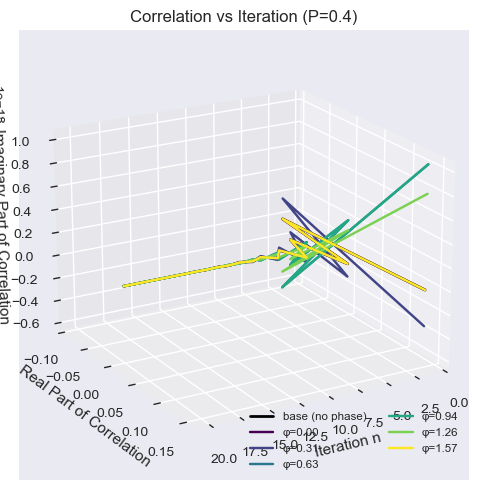

In [552]:
# Multi-phase log(|correlation|) plot for phases in [0, pi/2]
phases = np.linspace(0, np.pi/2, 6)  # more phase samples
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.viridis(np.linspace(0, 1, len(phases)))

# baseline (no phase) using existing em_base if available
try:
    corr_base_vals = np.array([pem_even(P, 0).correlation(O, k) for k in n])
    ax.plot(n, np.real(corr_base_vals), np.imag(corr_base_vals), color='k', linewidth=2, label='base (no phase)')
except Exception:
    print('Error')
    pass

for phi, c in zip(phases, colors):
    try:
        em_phi = pem_even(P, phi)
        corr_phi = np.array([em_phi.correlation(O, k) for k in n])
        ax.plot(n, np.real(corr_phi), np.imag(corr_phi), color=c, label=f'φ={phi:.2f}')
    except Exception:
        # skip phases that fail
        continue

plt.xlabel('Iteration n')
plt.ylabel('Real Part of Correlation')
ax.set_zlabel('Imaginary Part of Correlation')
plt.title(f'Correlation vs Iteration (P={P})')
plt.grid(True, alpha=0.3)
ax.view_init(elev=20, azim=60)
plt.legend(loc='lower right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

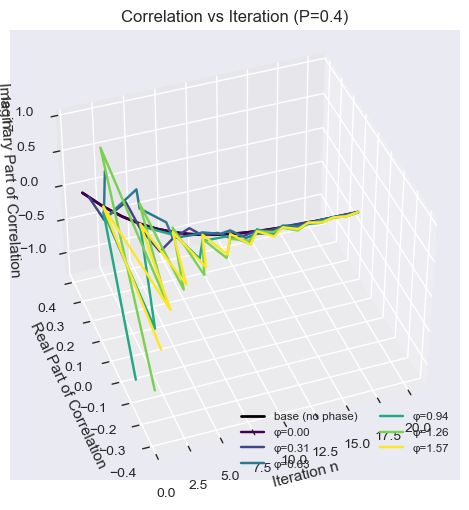

In [553]:
# Multi-phase log(|correlation|) plot for phases in [0, pi/2]
phases = np.linspace(0, np.pi/2, 6)  # more phase samples
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.viridis(np.linspace(0, 1, len(phases)))

# baseline (no phase) using existing em_base if available
try:
    corr_base_vals = np.array([pem_even(P, 0).correlation(O2, k) for k in n])
    ax.plot(n, np.real(corr_base_vals), np.imag(corr_base_vals), color='k', linewidth=2, label='base (no phase)')
except Exception:
    print('Error')
    pass

for phi, c in zip(phases, colors):
    try:
        em_phi = pem_even(P, phi)
        corr_phi = np.array([em_phi.correlation(O2, k) for k in n])
        ax.plot(n, np.real(corr_phi), np.imag(corr_phi), color=c, label=f'φ={phi:.2f}')
    except Exception:
        # skip phases that fail
        continue

plt.xlabel('Iteration n')
plt.ylabel('Real Part of Correlation')
ax.set_zlabel('Imaginary Part of Correlation')
plt.title(f'Correlation vs Iteration (P={P})')
plt.grid(True, alpha=0.3)
ax.view_init(elev=40, azim=250)
plt.legend(loc='lower right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

### 3D Phase Sweep (O observable)


- Purpose: Plot `corr(n)` in 3D (real vs imaginary vs iteration) for multiple phases.
- Output: One line per phase; camera view is preset but can be rotated.
- Use: Compare path geometry to assess phase effects beyond simple magnitude plots.


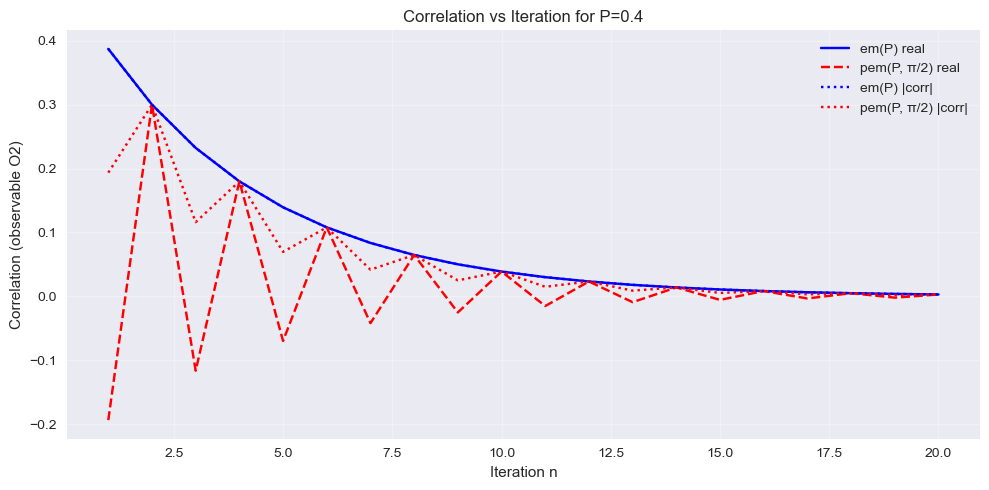

In [554]:
# Plot correlation function for em(P) and pem(P, pi/2)
# Uses existing: T_even_process, em_even, EM, O (observable), np, plt

# fallback for P if not defined earlier in the notebook
try:
    P
except NameError:
    P = 0.4

PHASE = np.pi/3
def pem_even(p, phi):
    """
    Phase-modified even-process EMachine:
    multiply the second symbol's transition slice by exp(i*phi).
    """
    return PEM(T_even_process(p).astype(complex), np.array([0, phi]))

n = np.arange(1,21)

em_base = em_even(P)
em_phase = pem_even(P, PHASE)
corr_base = np.array([em_base.correlation(O2, k) for k in n])
corr_phase = np.array([em_phase.correlation(O2, k) for k in n])

plt.figure(figsize=(10, 5))
plt.plot(n, np.real(corr_base), 'b-', label='em(P) real')
plt.plot(n, np.real(corr_phase), 'r--', label='pem(P, π/2) real')
plt.plot(n, np.abs(corr_base), 'b:', label='em(P) |corr|')
plt.plot(n, np.abs(corr_phase), 'r:', label='pem(P, π/2) |corr|')

plt.xlabel('Iteration n')
plt.ylabel('Correlation (observable O2)')
plt.title(f'Correlation vs Iteration for P={P}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Correlation vs Iteration using $O_2$ (2D)


- Purpose: Repeat correlation comparison (base vs phase) using alternate observable `O2`.
- Plots: Real parts and absolute values vs `n`.
- Insight: Different observables can highlight different dynamical features.


In [ ]:

em_bird = bird




## 4. Pauli σ_z Correlation Analysis

Analysis of correlation functions using the Pauli Z observable σ_z = [[1, 0], [0, -1]].


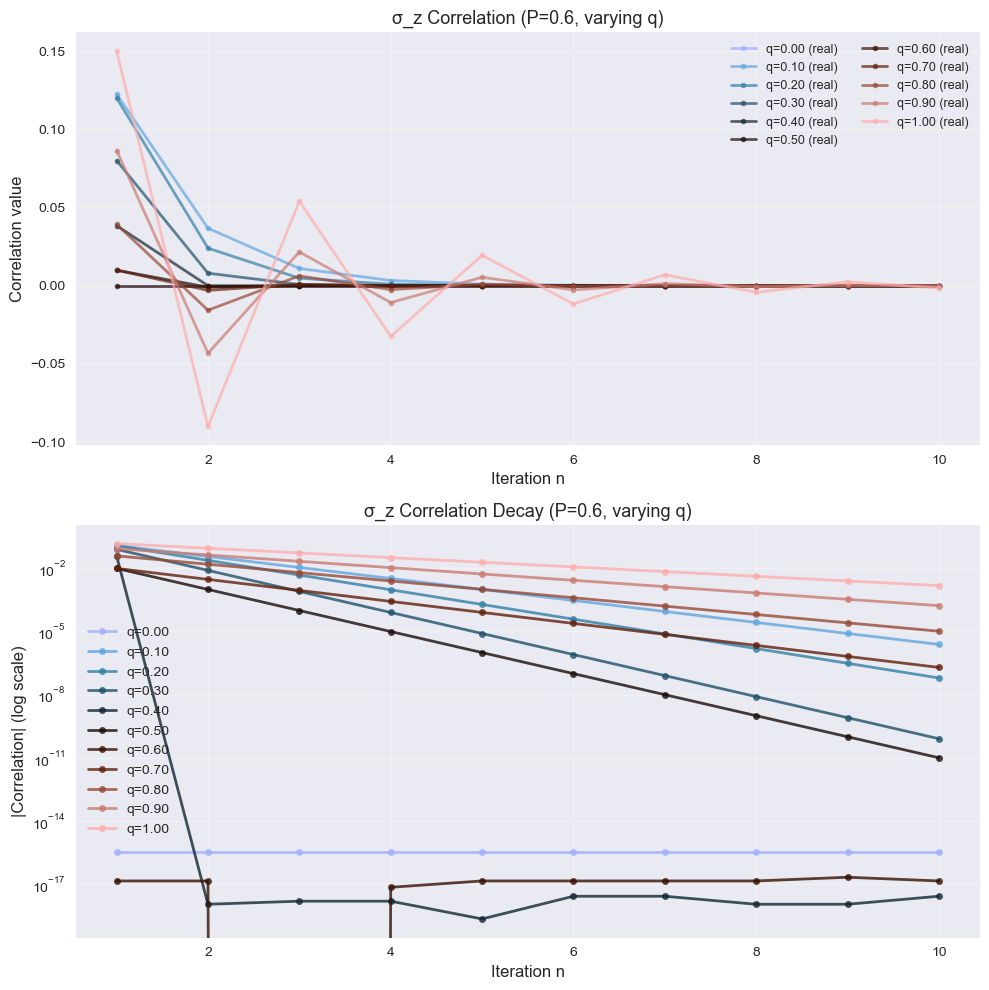

σ_z Correlation Analysis with w_bird (fixed P=0.6, varying q)
q values tested: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [556]:
# Define Pauli σ_z observable
sigma_z = np.array([[1, 0], [0, -1]])

# Set up parameters
P = 0.6  # Fixed parameter
q_values = np.linspace(0,1,11)  # Varying parameter
n = np.arange(1, 11)

# Create color map for different q values
colors = plt.cm.berlin(np.linspace(0, 1, len(q_values)))

# Create figure with two subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for each q value on the same graph
for idx, (q, color) in enumerate(zip(q_values, colors)):
    # Create bird EMachine with parameters (P, q)
    em_bird = w_bird(P, q)
    
    # Compute correlations using σ_z
    corr_bird_z = np.array([em_bird.correlation(sigma_z, k) for k in n])
    
    # Plot 1 (top): Real part and absolute value overlaid
    axes[0].plot(n, np.real(corr_bird_z), 'o-', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (real)', alpha=0.7)
    #axes[0].plot(n, np.abs(corr_bird_z), 's--', color=color, linewidth=2, 
    #             markersize=4, label=f'q={q:.2f} (|corr|)', alpha=0.7)
    
    # Plot 2 (bottom): Log scale
    axes[1].semilogy(n, np.abs(corr_bird_z), 'o-', color=color, linewidth=2, 
                     markersize=5, label=f'q={q:.2f}', alpha=0.8)

# Configure top plot
axes[0].set_xlabel('Iteration n', fontsize=12)
axes[0].set_ylabel('Correlation value', fontsize=12)
axes[0].set_title(f'σ_z Correlation (P={P}, varying q)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='best', ncol=2)

# Configure bottom plot
axes[1].set_xlabel('Iteration n', fontsize=12)
axes[1].set_ylabel('|Correlation| (log scale)', fontsize=12)
axes[1].set_title(f'σ_z Correlation Decay (P={P}, varying q)', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"σ_z Correlation Analysis with w_bird (fixed P={P}, varying q)")
print(f"q values tested: {q_values}")


### Pauli σ_x Correlation Analysis

Analysis of correlation functions using the Pauli X observable σ_x = [[0, 1], [1, 0]].

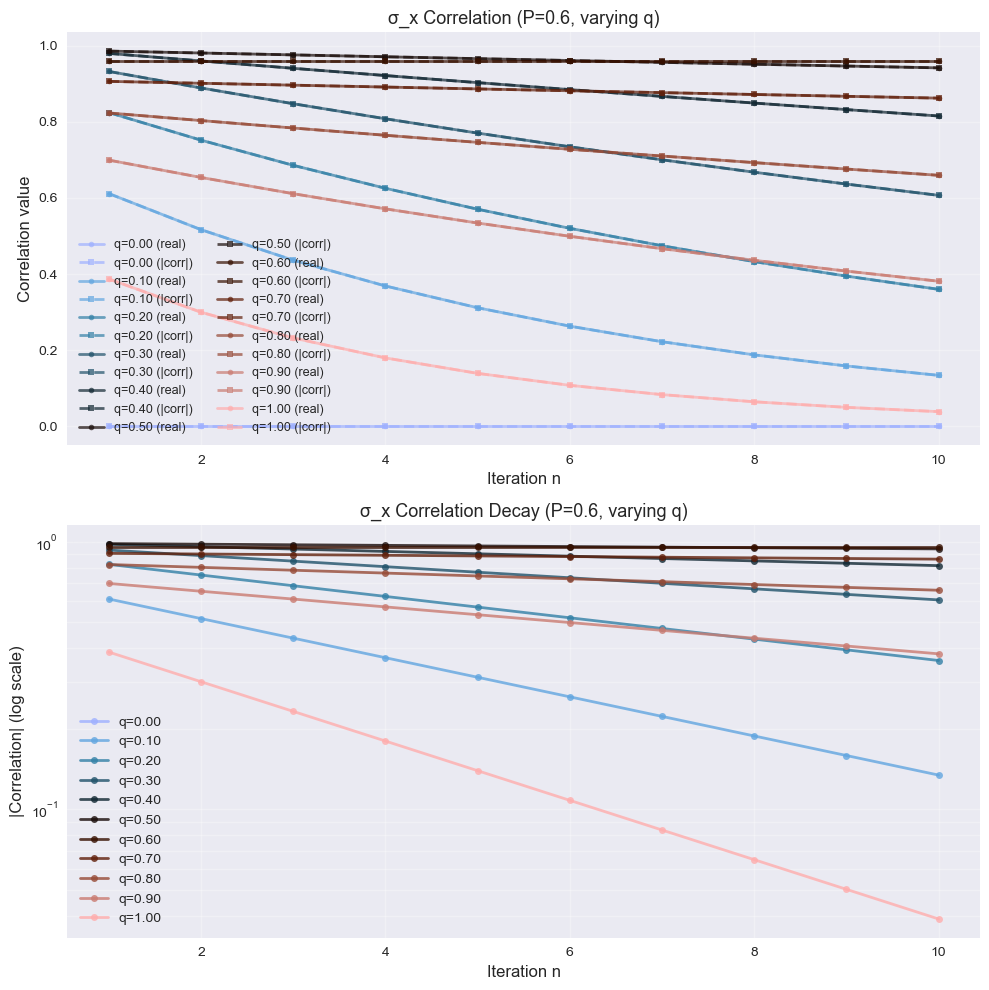

σ_x Correlation Analysis with w_bird (fixed P=0.6, varying q)
q values tested: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [557]:
# Define Pauli σ_x observable
sigma_x = np.array([[0, 1], [1, 0]])

# Set up parameters (same as σ_z analysis)
P = 0.6  # Fixed parameter
q_values = np.linspace(0, 1, 11)  # Varying parameter
n = np.arange(1, 11)

# Create color map for different q values
colors = plt.cm.berlin(np.linspace(0, 1, len(q_values)))

# Create figure with two subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for each q value on the same graph
for idx, (q, color) in enumerate(zip(q_values, colors)):
    # Create bird EMachine with parameters (P, q)
    em_bird = w_bird(P, q)
    
    # Compute correlations using σ_x
    corr_bird_x = np.array([em_bird.correlation(sigma_x, k) for k in n])
    
    # Plot 1 (top): Real part and absolute value overlaid
    axes[0].plot(n, np.real(corr_bird_x), 'o-', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (real)', alpha=0.7)
    axes[0].plot(n, np.abs(corr_bird_x), 's--', color=color, linewidth=2, 
                 markersize=4, label=f'q={q:.2f} (|corr|)', alpha=0.7)
    
    # Plot 2 (bottom): Log scale
    axes[1].semilogy(n, np.abs(corr_bird_x), 'o-', color=color, linewidth=2, 
                     markersize=5, label=f'q={q:.2f}', alpha=0.8)

# Configure top plot
axes[0].set_xlabel('Iteration n', fontsize=12)
axes[0].set_ylabel('Correlation value', fontsize=12)
axes[0].set_title(f'σ_x Correlation (P={P}, varying q)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='best', ncol=2)

# Configure bottom plot
axes[1].set_xlabel('Iteration n', fontsize=12)
axes[1].set_ylabel('|Correlation| (log scale)', fontsize=12)
axes[1].set_title(f'σ_x Correlation Decay (P={P}, varying q)', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"σ_x Correlation Analysis with w_bird (fixed P={P}, varying q)")
print(f"q values tested: {q_values}")


### Asymptotic Variance Analysis (Bird process)

Analysis of asymptotic variance across varying Q parameter with fixed P for the w_bird process.

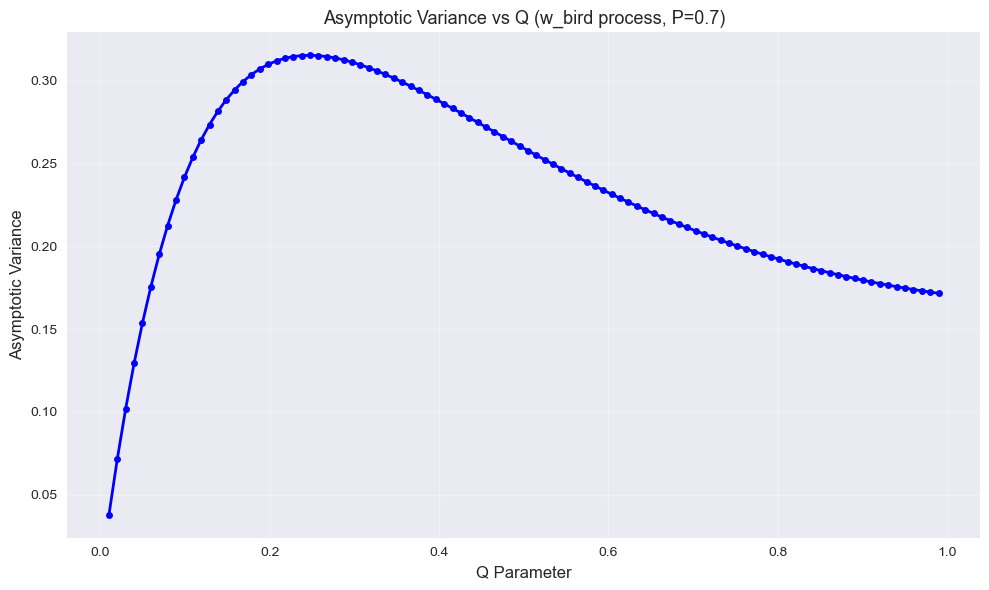

Asymptotic variance analysis for w_bird(P=0.7, Q)
Q range: 0.01 to 0.99
Variance range: 0.0380 to 0.3154


In [600]:
# Asymptotic variance analysis for w_bird process
# Fix P, vary Q - using built-in asymptotic_variance method

# Fix P parameter
P_fixed = 0.7
Q_values = np.linspace(0.01, 0.99, 100)  # Vary Q across this range

# Define the discrete function for asymptotic variance
# This is a function that maps state indices to values
# For a binary system, we have 2 states
# Use [0, 1] to compute variance on the second state
f_func = np.array([1, 0])

em = np.array([w_bird(P_fixed, q) for q in Q_values])
asym_var = np.array([m.asymptotic_variance(f_func) for m in em])
plt.figure(figsize=(10, 6))
plt.plot(Q_values, asym_var, 'bo-', linewidth=2, markersize=5)
plt.xlabel('Q Parameter', fontsize=12)
plt.ylabel('Asymptotic Variance', fontsize=12)
plt.title(f'Asymptotic Variance vs Q (w_bird process, P={P_fixed})', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Asymptotic variance analysis for w_bird(P={P_fixed}, Q)")
print(f"Q range: {Q_values[0]:.2f} to {Q_values[-1]:.2f}")
print(f"Variance range: {np.nanmin(asym_var):.4f} to {np.nanmax(asym_var):.4f}")

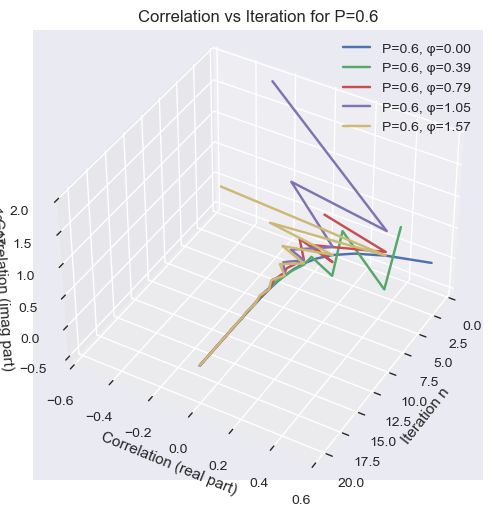

In [583]:
# Plot correlation function for em(P) and pem(P, multiple phases) in 3D
# Uses existing: T_even_process, em_even, PEM, O2 (observable), np, plt

# fallback for P if not defined earlier in the notebook
try:
    P
except NameError:
    P = 0.4

PHASE = [0, np.pi/8, np.pi/4, np.pi/3, np.pi/2]
def pem_even(p, phi):
    """
    Phase-modified even-process EMachine:
    multiply the second symbol's transition slice by exp(i*phi).
    """
    return PEM(T_even_process(p).astype(complex), np.array([0, phi]))

n = np.arange(1,21)

# create phased EMachines for each phase
em_phase = [pem_even(P, phi) for phi in PHASE]

# create a 3D axes properly
fig2 = plt.figure(figsize=(10, 5))
ax2 = fig2.add_subplot(111, projection='3d')

for em, phi in zip(em_phase, PHASE):
    corr_phase = np.array([em.correlation(O2, k) for k in n])
    ax2.plot(n, np.real(corr_phase), np.imag(corr_phase), label=f'P={P}, φ={phi:.2f}')

ax2.set_xlabel('Iteration n')
ax2.set_ylabel('Correlation (real part)')
ax2.set_zlabel('Correlation (imag part)')
ax2.set_title(f'Correlation vs Iteration for P={P}')
# set viewing angle (elevation, azimuth)
ax2.view_init(elev=40, azim=30)
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

### 3D Correlation vs Iteration (multiple phases, $O_2$)


- Purpose: Show full complex trajectory for several phases using `O2`.
- View: Elevation/azimuth preset; rotate interactively as needed.
- Legend: Each line labeled with phase value for quick comparison.


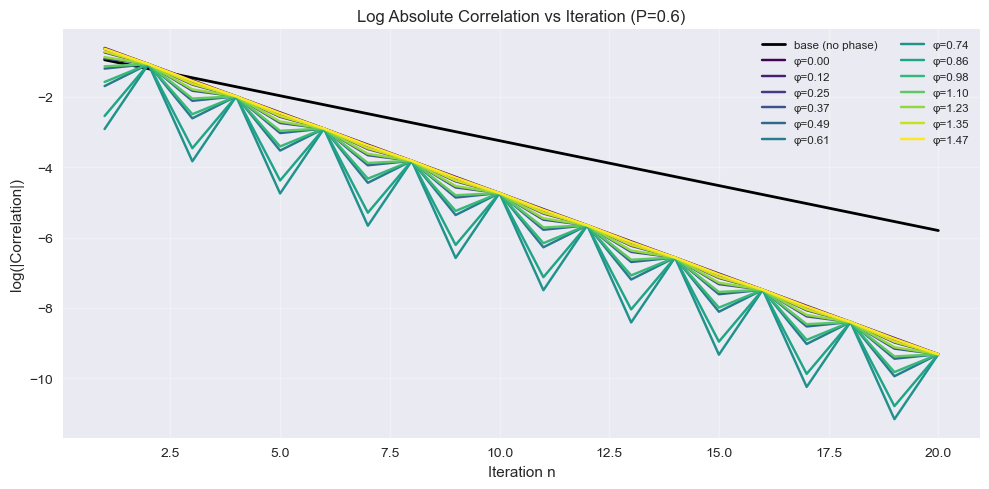

In [584]:
# Multi-phase log(|correlation|) plot for phases in [0, pi/2]
phases = np.linspace(0, np.pi/2-0.1, 13)  # more phase samples
plt.figure(figsize=(10, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(phases)))

# baseline (no phase) using existing em_base if available
try:
    corr_base_vals = np.array([em_base.correlation(O2, k) for k in n])
    y_base = np.log(np.clip(np.abs(corr_base_vals), 1e-300, None))
    plt.plot(n, y_base, color='k', linewidth=2, label='base (no phase)')
except Exception:
    pass

for phi, c in zip(phases, colors):
    try:
        em_phi = pem_even(P, phi)
        corr_phi = np.array([em_phi.correlation(O2, k) for k in n])
        y = np.log(np.clip(np.abs(corr_phi), 1e-300, None))
        plt.plot(n, y, color=c, label=f'φ={phi:.2f}')
    except Exception:
        # skip phases that fail
        continue

plt.xlabel('Iteration n')
plt.ylabel('log(|Correlation|)')
plt.title(f'Log Absolute Correlation vs Iteration (P={P})')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

# Plot correlation function for em(P) and pem(P, pi/2)
# Uses existing: T_even_process, em_even, EM, O (observable), np, plt

# fallback for P if not defined earlier in the notebook
try:
    P
except NameError:
    P = 0.4

PHASE = np.pi/2
def pem_even(p, phi):
    """
    Phase-modified even-process EMachine:
    multiply the second symbol's transition slice by exp(i*phi).
    """
    return PEM(T_even_process(p).astype(complex), np.array([0, phi]))

n = np.arange(1,21)

em_base = em_even(P)
em_phase = pem_even(P, PHASE)
corr_base = np.array([em_base.correlation(O, k) for k in n])
corr_phase = np.array([em_phase.correlation(O, k) for k in n])

plt.figure(figsize=(10, 5))
plt.plot(n, np.real(corr_base), 'b-', label='em(P) real')
plt.plot(n, np.real(corr_phase), 'r--', label='pem(P, π/2) real')
plt.plot(n, np.abs(corr_base), 'b:', label='em(P) |corr|')
plt.plot(n, np.abs(corr_phase), 'r:', label='pem(P, π/2) |corr|')

plt.xlabel('Iteration n')
plt.ylabel('Correlation (observable O)')
plt.title(f'Correlation vs Iteration for P={P}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Correlation Length Analysis (Even Process)


- Purpose: Compute and plot correlation length across `P∈(0,1)`.
- Output: 2D curve of correlation length vs `P` with finite-range clipping for clarity.
- Note: Infinite/very large values are handled (clipped/NaN) to keep the plot readable.


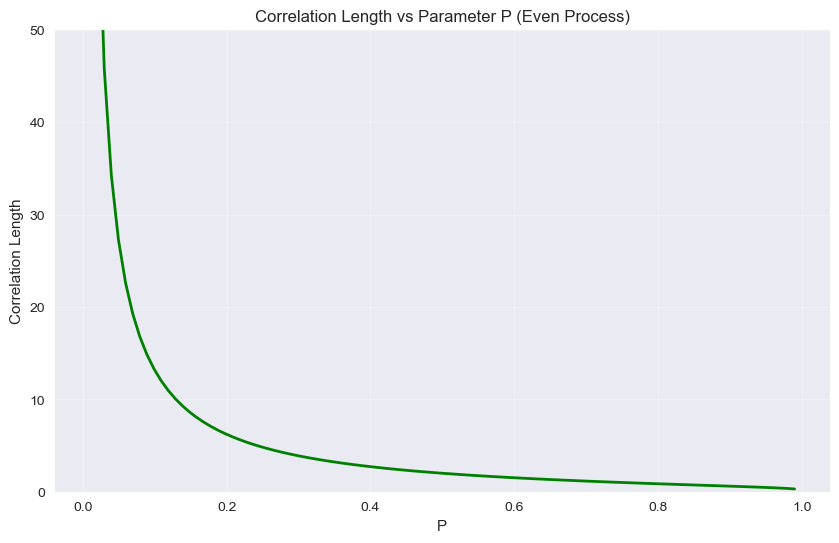

In [585]:
# Correlation length analysis
def correlation_length_analysis():
    """
    Analyze correlation length as a function of parameter P
    """
    p_values = np.linspace(0.01, 0.99, 100)
    corr_lengths = []
    
    for p in p_values:
        try:
            em_p = em_even(p)
            cl = em_p.correlation_length()
            corr_lengths.append(cl if np.isfinite(cl) else np.nan)
        except:
            corr_lengths.append(np.nan)
    
    corr_lengths = np.array(corr_lengths)
    
    plt.figure(figsize=(10, 6))
    plt.plot(p_values, corr_lengths, 'g-', linewidth=2)
    plt.xlabel('P')
    plt.ylabel('Correlation Length')
    plt.title('Correlation Length vs Parameter P (Even Process)')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 50)  # Limit y-axis for better visualization
    plt.show()
    
    return p_values, corr_lengths

p_corr, corr_lengths = correlation_length_analysis()

## 2. Upset Gambler Process

The upset gambler process involves two parameters P and Q representing different transition probabilities.

In [586]:
# Upset gambler transition tensor
def T_upset_gambler(p, q):
    """
    Transition tensor for upset gambler with parameters p and q
    """
    return np.array([[[0, p], [q, 0]],
                     [[1-p, 0], [1-q, 0]]])**(1/2)

# Create EMachine factory function
em_gambler = lambda p, q: EM(T_upset_gambler(p, q))

# Test with specific parameters
P_g, Q_g = 0.8, 0.6
T_gambler = T_upset_gambler(P_g, Q_g)
em_g = EM(T_gambler)

print(f"Upset gambler with P = {P_g}, Q = {Q_g}")
print(f"Transition tensor shape: {T_gambler.shape}")
print(f"EMachine dimension: {em_g.dim}")

# Eigenvalues and correlation length
print(f"\nEigenvalues of E matrix:")
print(em_g.eig_r[0])
print(f"Correlation length: {em_g.correlation_length():.3f}")

# Memory measures
print(f"\nMemory measures:")
print(f"Statistical memory: {em_g.statistical_memory():.3f}")
print(f"Quantum statistical memory: {em_g.quantum_statistical_memory():.3f}")
print(f"Topological memory: {em_g.topological_memory():.3f}")

Upset gambler with P = 0.8, Q = 0.6
Transition tensor shape: (2, 2, 2)
EMachine dimension: 2

Eigenvalues of E matrix:
[-0.8         1.          0.69282032 -0.69282032]
Correlation length: 3.106

Memory measures:
Statistical memory: 0.991
Quantum statistical memory: 0.238
Topological memory: 1.000


### Complex Observable Analysis (Upset Gambler)


- Purpose: Evaluate real/imag components of a complex observable over `n`.
- Outputs: 3-panel figure (3D evolution, 3D log evolution, 2D components).
- Insight: Visualize oscillations and decay in both raw and log-transformed spaces.


/Users/ernestchan/Desktop/Msc/emachine_v2.py:311: ComplexWarning: Casting complex values to real discards the imaginary part
  X = np.tensordot(self.A, O.astype(self.A.dtype), axes = ([0],[0]))
/var/folders/21/h8xsn48s3_nfh_2qh8ddbz5w0000gn/T/ipykernel_45124/2331168118.py:29: RuntimeWarning: divide by zero encountered in log
  y2_real = np.real(np.log(obs))
/var/folders/21/h8xsn48s3_nfh_2qh8ddbz5w0000gn/T/ipykernel_45124/2331168118.py:30: RuntimeWarning: divide by zero encountered in log
  z2_imag = np.imag(np.log(obs))


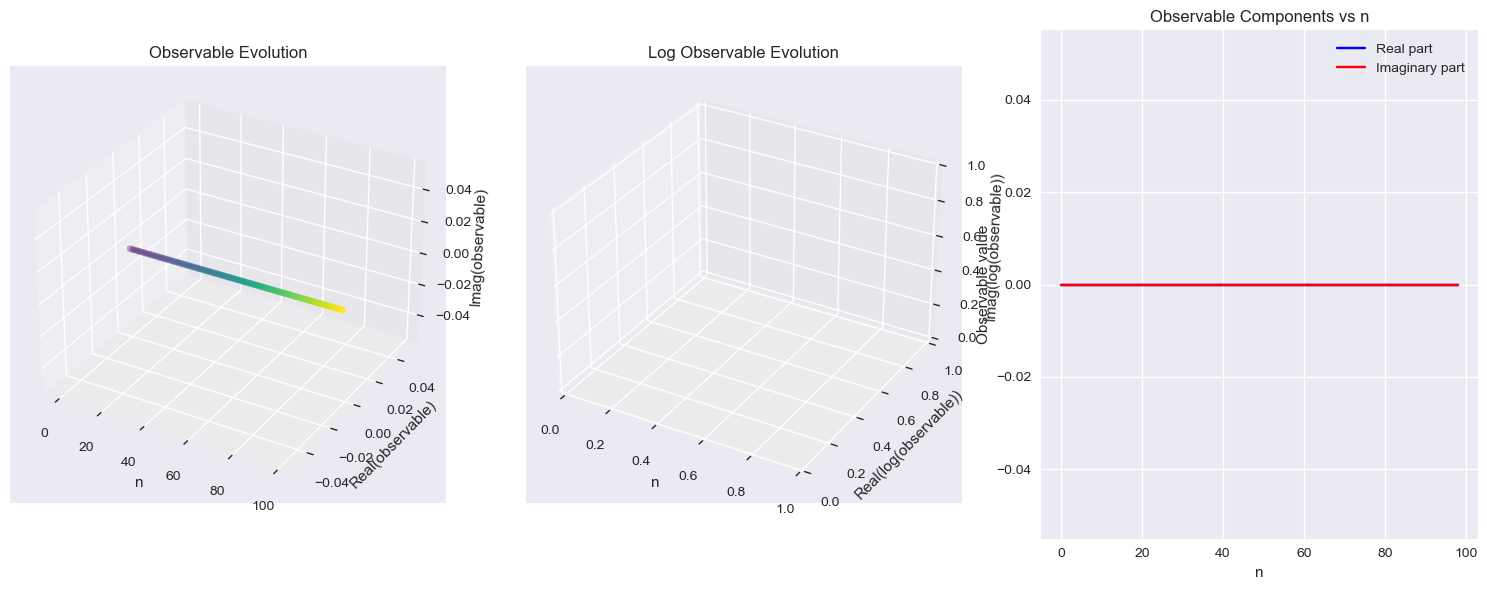

In [587]:
# Complex observable analysis for upset gambler
def upset_gambler_observable_analysis():
    """
    Analyze complex observables for the upset gambler process
    """
    # Complex observable matrix
    O_complex = np.array([[0, -1j], [1j, 0]])
    
    n = np.arange(1, 100)
    obs = np.array([em_g.observable(O_complex, l) for l in n])
    
    # Real and imaginary parts
    x = np.arange(len(obs))
    y_real = np.real(obs)
    z_imag = np.imag(obs)
    
    fig = plt.figure(figsize=(15, 6))
    
    # 3D plot of observable evolution
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(x, y_real, z_imag, c=x, cmap='viridis')
    ax1.set_xlabel('n')
    ax1.set_ylabel('Real(observable)')
    ax1.set_zlabel('Imag(observable)')
    ax1.set_title('Observable Evolution')
    
    # 3D plot of log observable
    ax2 = fig.add_subplot(132, projection='3d')
    y2_real = np.real(np.log(obs))
    z2_imag = np.imag(np.log(obs))
    ax2.scatter(x, y2_real, z2_imag, c=x, cmap='plasma')
    ax2.set_xlabel('n')
    ax2.set_ylabel('Real(log(observable))')
    ax2.set_zlabel('Imag(log(observable))')
    ax2.set_title('Log Observable Evolution')
    
    # 2D plots
    ax3 = fig.add_subplot(133)
    ax3.plot(x, y_real, 'b-', label='Real part')
    ax3.plot(x, z_imag, 'r-', label='Imaginary part')
    ax3.set_xlabel('n')
    ax3.set_ylabel('Observable value')
    ax3.set_title('Observable Components vs n')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return obs

obs_complex = upset_gambler_observable_analysis()

### Parameter Space Scan (Upset Gambler: P, Q)


- Purpose: Map memory measures and correlation length over a grid of `(P,Q)`.
- Outputs: Three 3D surfaces for Quantum/Statistical memory and Correlation length.
- Notes: Values are clipped/NaN-handled to improve readability; adjust grid for speed/quality.


Computing parameter space analysis...
Progress: 0.0%
Progress: 16.7%
Progress: 33.3%
Progress: 50.0%
Progress: 66.7%
Progress: 83.3%


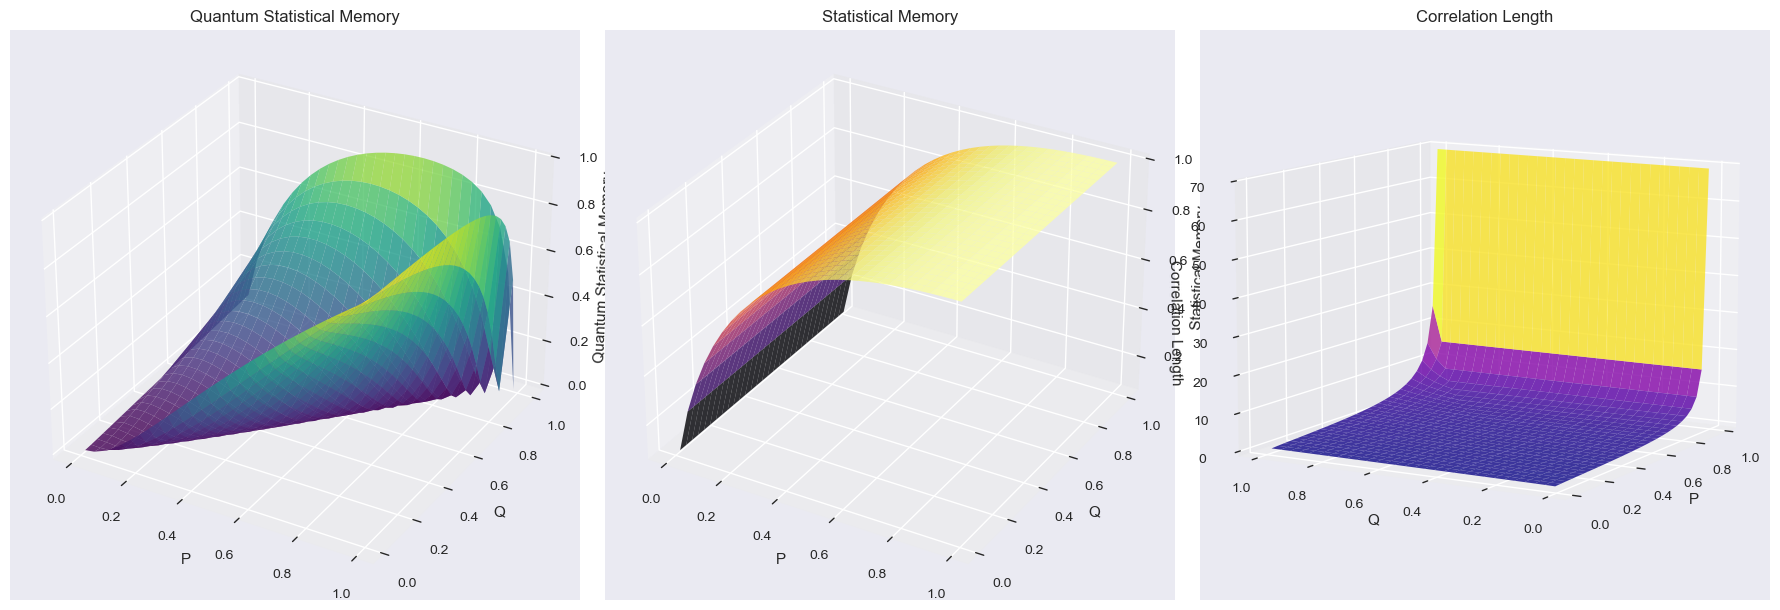

In [588]:
# 2D parameter space analysis for upset gambler
def gambler_parameter_space_analysis():
    """
    Analyze memory measures across the (P, Q) parameter space
    """
    X = np.linspace(0.01, 0.99, 30)  # Reduced resolution for faster computation
    Y = np.linspace(0.01, 0.99, 30)
    
    meshX, meshY = np.meshgrid(X, Y)
    
    # Initialize arrays for different memory measures
    qsm = np.zeros_like(meshX)
    sm = np.zeros_like(meshX)
    cl = np.zeros_like(meshX)
    
    print("Computing parameter space analysis...")
    for i, x in enumerate(X):
        if i % 5 == 0:
            print(f"Progress: {i/len(X)*100:.1f}%")
        for j, y in enumerate(Y):
            try:
                em_temp = em_gambler(x, y)
                qsm[j, i] = em_temp.quantum_statistical_memory()
                sm[j, i] = em_temp.statistical_memory()
                cl_temp = em_temp.correlation_length()
                cl[j, i] = cl_temp if np.isfinite(cl_temp) and cl_temp < 100 else np.nan
            except:
                qsm[j, i] = np.nan
                sm[j, i] = np.nan
                cl[j, i] = np.nan
    
    # Create 3D plots
    fig = plt.figure(figsize=(18, 6))
    
    # Quantum Statistical Memory
    ax1 = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(meshX, meshY, qsm, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('P')
    ax1.set_ylabel('Q')
    ax1.set_zlabel('Quantum Statistical Memory')
    ax1.set_title('Quantum Statistical Memory')
    
    # Statistical Memory
    ax2 = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(meshX, meshY, sm, cmap='inferno', alpha=0.8)
    ax2.set_xlabel('P')
    ax2.set_ylabel('Q')
    ax2.set_zlabel('Statistical Memory')
    ax2.set_title('Statistical Memory')
    
    # Correlation Length
    ax3 = fig.add_subplot(133, projection='3d')
    surf3 = ax3.plot_surface(meshX, meshY, cl, cmap='plasma', alpha=0.8)
    ax3.view_init(elev=10, azim=210)
    ax3.set_xlabel('P')
    ax3.set_ylabel('Q')
    ax3.set_zlabel('Correlation Length')
    ax3.set_title('Correlation Length')
    
    plt.tight_layout()
    plt.show()
    
    return meshX, meshY, qsm, sm, cl

meshX, meshY, qsm, sm, cl = gambler_parameter_space_analysis()

## 3. Three-State Systems

Analysis of more complex three-state stochastic processes.

In [589]:
# Three-state system with multiple parameters
def T_three_state_1(p):
    """
    Simple three-state system with cyclic structure
    """
    return np.array([[[1-p, 0, 0],
                      [p, 0, 0],
                      [0, 0, 0]],
                     [[0, 0, 0],
                      [0, 1-p, 0],
                      [0, p, 0]],
                     [[0, 0, p],
                      [0, 0, 0],
                      [0, 0, 1-p]]])

def T_three_state_2(p, q, r):
    """
    More complex three-state system with multiple parameters
    """
    return np.array([[[1-p, 0, 0],
                      [0, 0, 0],
                      [r, 0, 0]],
                     [[0, p, 0],
                      [0, 1-q, 0],
                      [0, 0, 0]],
                     [[0, 0, 0],
                      [0, 0, q],
                      [0, 0, 1-r]]])**(1/2)

# Test both systems
P_3 = 0.4
em_3state_1 = EM(T_three_state_1(P_3))

P_3, Q_3, R_3 = 0.4, 0.8, 0.2
em_3state_2 = EM(T_three_state_2(P_3, Q_3, R_3))

print("=== Three-State System 1 (Cyclic) ===")
print(f"Parameter P = {P_3}")
print(f"Lambda matrix diagonal:")
print(np.diag(em_3state_1.lam))
print(f"Statistical memory: {em_3state_1.statistical_memory():.3f}")

print("\n=== Three-State System 2 (Complex) ===")
print(f"Parameters P = {P_3}, Q = {Q_3}, R = {R_3}")
print(f"Classical eigenvalues:")
print(em_3state_2.eig_r_classical[0])
print(f"Statistical memory: {em_3state_2.statistical_memory():.3f}")

=== Three-State System 1 (Cyclic) ===
Parameter P = 0.4
Lambda matrix diagonal:
[0.80064077 0.42365927 0.42365927]
Statistical memory: 1.585+0.000j

=== Three-State System 2 (Complex) ===
Parameters P = 0.4, Q = 0.8, R = 0.2
Classical eigenvalues:
[1. +0.j         0.3+0.26457513j 0.3-0.26457513j]
Statistical memory: 1.379+0.000j


### Stochastic Convergence vs Theoretical Prediction


- Purpose: Compare Monte Carlo cumulative averages to theoretical emission predictions.
- Method: Log-spaced sampling points for theory; long-run cumulative average for simulation.
- Output: Semi-log plots for several `P` values with overlays of theory vs simulation.


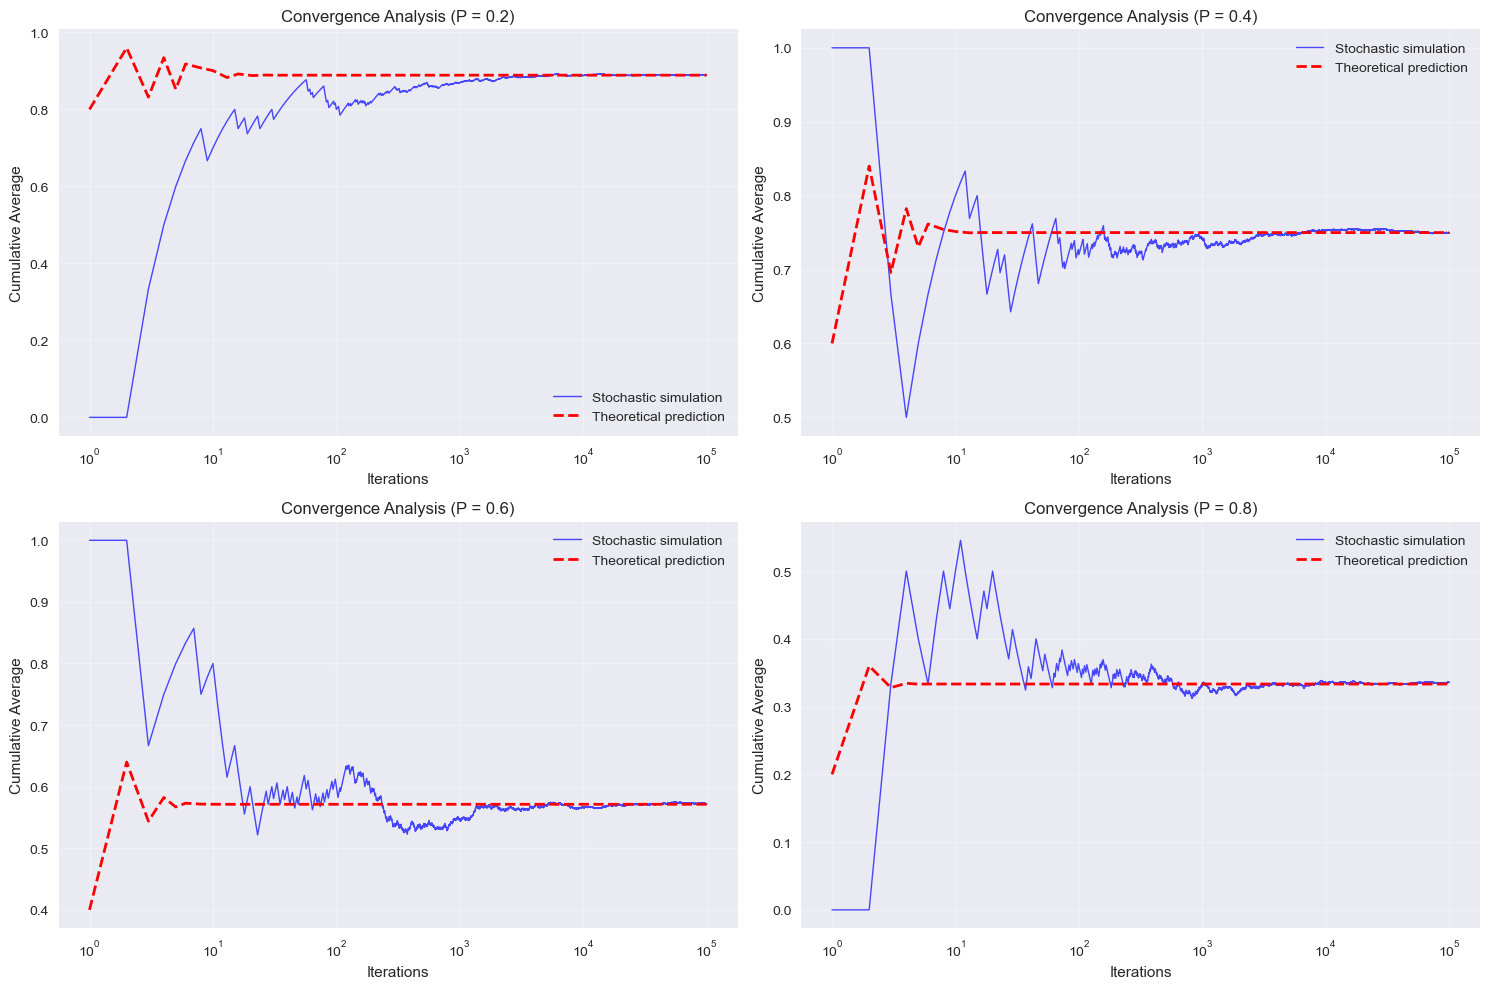

In [590]:
# Stochastic simulation analysis
def stochastic_convergence_analysis():
    """
    Compare stochastic simulations with theoretical emission distributions
    """
    n_iterations = 100000
    n_range = np.arange(1, n_iterations + 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Parameters to test
    test_params = [0.2, 0.4, 0.6, 0.8]
    
    for idx, p in enumerate(test_params):
        ax = axes[idx//2, idx%2]
        
        # Stochastic simulation
        em_p = em_even(p)
        stoch_data = em_p.propagator(n_iterations, np.array([1, 0]))
        stoch_cumavg = np.cumsum(stoch_data) / n_range
        
        # Theoretical emission distribution (sample at regular intervals)
        sample_points = np.logspace(0, np.log10(n_iterations), 50).astype(int)
        em_dist_sampled = []
        for i in sample_points:
            dist = em_p.emission_distribution(i)
            expected = np.sum(dist.T @ np.array([1, 0]) * np.array([0, 1]))
            em_dist_sampled.append(expected)
        
        # Plot results
        ax.semilogx(n_range, stoch_cumavg, 'b-', alpha=0.7, linewidth=1, label='Stochastic simulation')
        ax.semilogx(sample_points, em_dist_sampled, 'r--', linewidth=2, label='Theoretical prediction')
        
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Cumulative Average')
        ax.set_title(f'Convergence Analysis (P = {p})')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

stochastic_convergence_analysis()

### Variance, Std Dev, Coefficient of Variation


- Purpose: Study scaling of variance-related quantities over `n` for multiple `P`.
- Outputs: Three log-log subplots (variance, std dev, CV) to assess asymptotic behavior.
- Note: Handles potential non-finite values; legends annotate parameter settings.


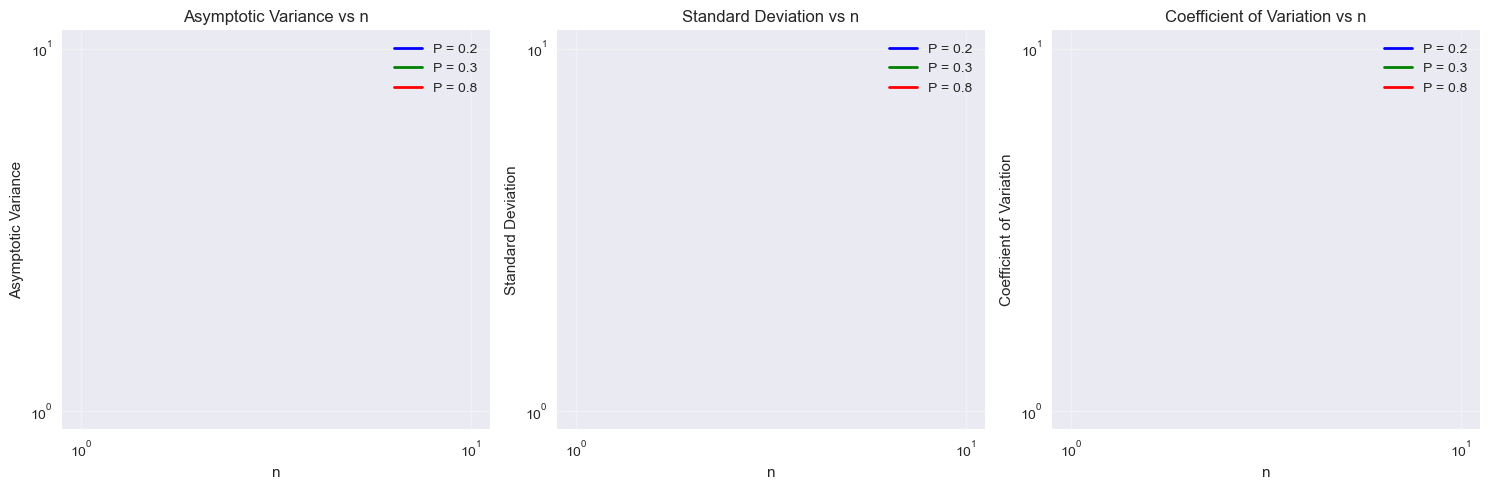

In [591]:
# Variance analysis and asymptotic behavior
def variance_analysis():
    """
    Analyze asymptotic variance and its relationship to convergence
    """
    n_range = np.logspace(1, 4, 50).astype(int)
    
    plt.figure(figsize=(15, 5))
    
    test_params = [0.2, 0.3, 0.8]
    colors = ['blue', 'green', 'red']
    
    for p, color in zip(test_params, colors):
        em_p = em_even(p)
        
        # Compute asymptotic variance
        variances = []
        for n in n_range:
            try:
                var = em_p.asymptotic_variance(np.array([0, 1]), n)
                variances.append(var if np.isfinite(var) and var > 0 else np.nan)
            except:
                variances.append(np.nan)
        
        variances = np.array(variances)
        
        # Plot variance
        plt.subplot(1, 3, 1)
        plt.loglog(n_range, variances, color=color, linewidth=2, label=f'P = {p}')
        
        # Plot standard deviation
        plt.subplot(1, 3, 2)
        std_devs = np.sqrt(variances)
        plt.loglog(n_range, std_devs, color=color, linewidth=2, label=f'P = {p}')
        
        # Plot coefficient of variation
        plt.subplot(1, 3, 3)
        # Theoretical mean for binary process
        mean_val = p
        cv = std_devs / mean_val
        plt.loglog(n_range, cv, color=color, linewidth=2, label=f'P = {p}')
    
    plt.subplot(1, 3, 1)
    plt.xlabel('n')
    plt.ylabel('Asymptotic Variance')
    plt.title('Asymptotic Variance vs n')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.xlabel('n')
    plt.ylabel('Standard Deviation')
    plt.title('Standard Deviation vs n')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.xlabel('n')
    plt.ylabel('Coefficient of Variation')
    plt.title('Coefficient of Variation vs n')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

variance_analysis()

## 5. Summary and Comparative Analysis

This section provides summary visualizations comparing different processes and their key properties.

/opt/anaconda3/envs/physics_3_11_9/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/opt/anaconda3/envs/physics_3_11_9/lib/python3.11/site-packages/matplotlib/text.py:906: ComplexWarning: Casting complex values to real discards the imaginary part
  y = float(self.convert_yunits(self._y))
/opt/anaconda3/envs/physics_3_11_9/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/opt/anaconda3/envs/physics_3_11_9/lib/python3.11/site-packages/matplotlib/text.py:763: ComplexWarning: Casting complex values to real discards the imaginary part
  posy = float(self.convert_yunits(y))


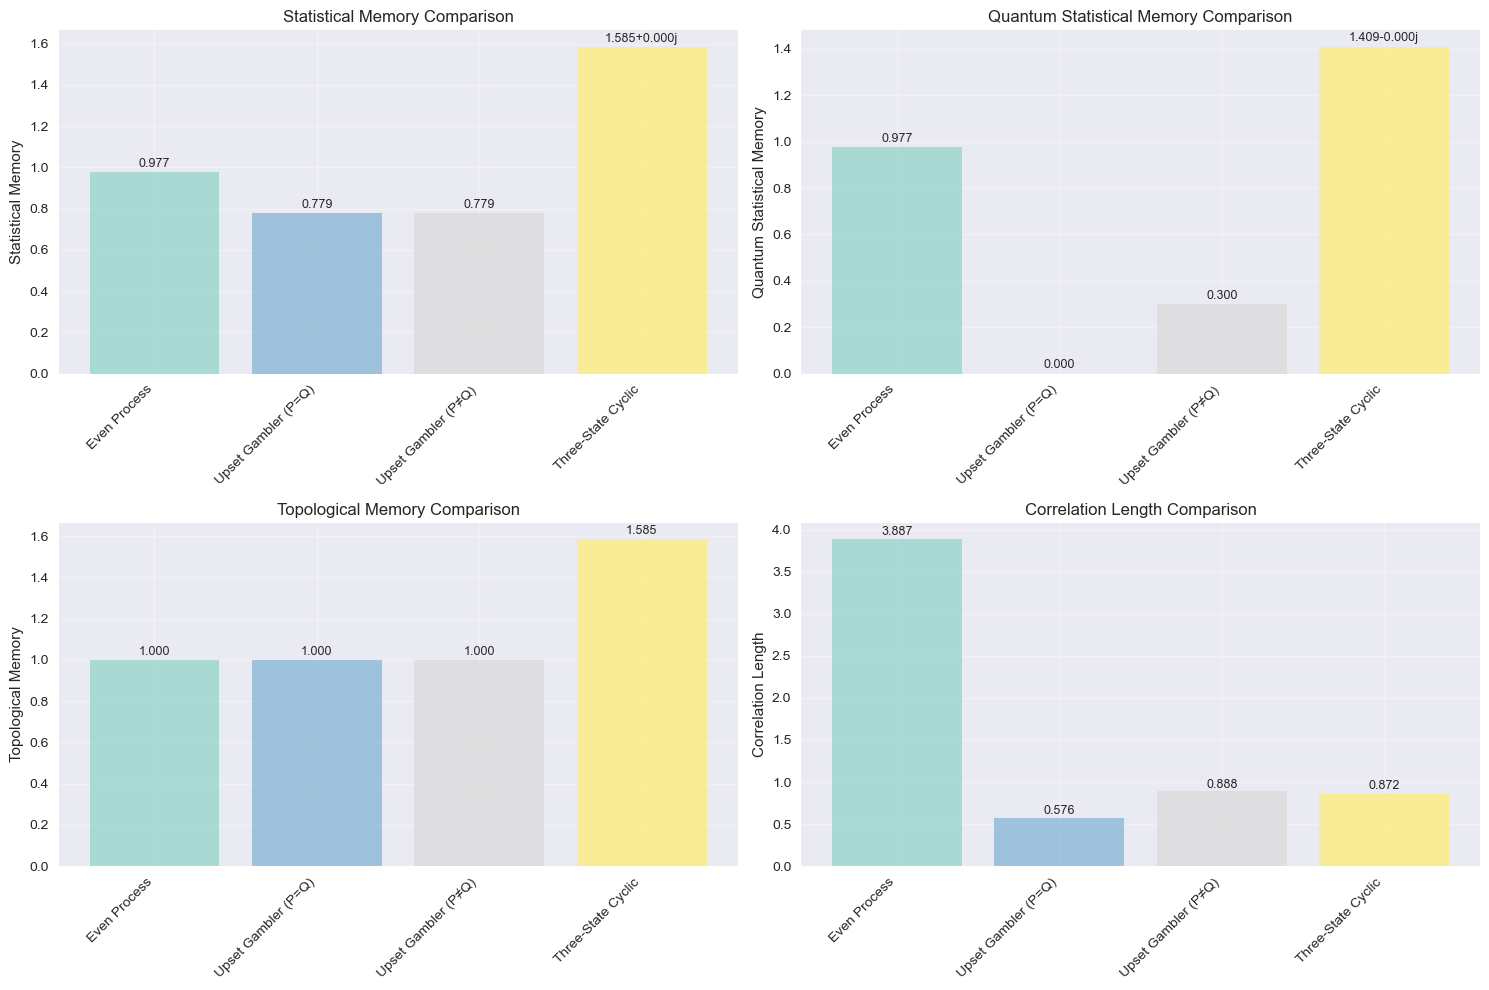

=== Numerical Comparison ===
Process                   Stat Mem   QStat Mem  Topo Mem   Corr Len  
----------------------------------------------------------------------
Even Process              0.977      0.977      1.000      3.887     
Upset Gambler (P=Q)       0.779      0.000      1.000      0.576     
Upset Gambler (P≠Q)       0.779      0.300      1.000      0.888     
Three-State Cyclic        1.585+0.000j 1.409-0.000j 1.585      0.872     


In [592]:
# Comparative analysis of different process types
def comparative_process_analysis():
    """
    Compare properties of different stochastic processes
    """
    # Parameters for comparison
    p_common = 0.3
    
    # Different processes
    processes = {
        'Even Process': em_even(p_common),
        'Upset Gambler (P=Q)': em_gambler(p_common, p_common),
        'Upset Gambler (P≠Q)': em_gambler(p_common, 0.7),
        'Three-State Cyclic': EM(T_three_state_1(p_common))
    }
    
    # Properties to compare
    properties = ['statistical_memory', 'quantum_statistical_memory', 'topological_memory', 'correlation_length']
    
    results = {}
    for name, em_process in processes.items():
        results[name] = {}
        for prop in properties:
            try:
                value = getattr(em_process, prop)()
                # Handle infinite correlation length
                if prop == 'correlation_length' and not np.isfinite(value):
                    value = 100  # Cap at 100 for visualization
                results[name][prop] = value
            except:
                results[name][prop] = np.nan
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    for idx, prop in enumerate(properties):
        ax = axes[idx//2, idx%2]
        
        names = list(results.keys())
        values = [results[name][prop] for name in names]
        
        bars = ax.bar(range(len(names)), values, alpha=0.7, 
                     color=plt.cm.Set3(np.linspace(0, 1, len(names))))
        
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_ylabel(prop.replace('_', ' ').title())
        ax.set_title(f'{prop.replace("_", " ").title()} Comparison')
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            if not np.isnan(value):
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print numerical results
    print("=== Numerical Comparison ===")
    print(f"{'Process':<25} {'Stat Mem':<10} {'QStat Mem':<10} {'Topo Mem':<10} {'Corr Len':<10}")
    print("-" * 70)
    for name, props in results.items():
        print(f"{name:<25} {props['statistical_memory']:<10.3f} "
              f"{props['quantum_statistical_memory']:<10.3f} "
              f"{props['topological_memory']:<10.3f} "
              f"{props['correlation_length']:<10.3f}")

comparative_process_analysis()

## 6. Interactive Analysis Tools

This section provides utility functions for custom analysis of any EMachine process.

In [593]:
# Utility functions for custom analysis
def analyze_custom_emachine(T, description="Custom Process"):
    """
    Comprehensive analysis of any EMachine transition tensor
    
    Parameters:
    T: transition tensor (shape: [num_symbols, dim, dim])
    description: string description of the process
    """
    print(f"=== {description} Analysis ===")
    
    # Create EMachine
    em = EM(T)
    
    # Basic properties
    print(f"Tensor shape: {T.shape}")
    print(f"Dimension: {em.dim}")
    print(f"Number of symbols: {T.shape[0]}")
    
    # Eigenvalues
    print(f"\nEigenvalues of E matrix:")
    eigs = em.eig_r[0]
    for i, eig in enumerate(eigs):
        print(f"  λ_{i}: {eig}")
    
    # Memory measures
    try:
        stat_mem = em.statistical_memory()
        print(f"\nStatistical Memory: {stat_mem:.4f}")
    except:
        print(f"\nStatistical Memory: Could not compute")
    
    try:
        qstat_mem = em.quantum_statistical_memory()
        print(f"Quantum Statistical Memory: {qstat_mem:.4f}")
    except:
        print(f"Quantum Statistical Memory: Could not compute")
    
    try:
        topo_mem = em.topological_memory()
        print(f"Topological Memory: {topo_mem:.4f}")
    except:
        print(f"Topological Memory: Could not compute")
    
    try:
        corr_len = em.correlation_length()
        if np.isfinite(corr_len):
            print(f"Correlation Length: {corr_len:.4f}")
        else:
            print(f"Correlation Length: Infinite")
    except:
        print(f"Correlation Length: Could not compute")
    
    # Canonical forms
    print(f"\nCanonical forms computed successfully")
    
    return em

# Example usage with a custom 2x2x2 tensor
print("Example: Custom symmetric process")
T_custom = np.array([[[0.3, 0.2],
                      [0.1, 0.4]],
                     [[0.7, 0.8],
                      [0.9, 0.6]]])

# Normalize to make it stochastic
for i in range(T_custom.shape[1]):
    T_custom[:, i, :] = T_custom[:, i, :] / np.sum(T_custom[:, i, :], axis=(0, 1)) * T_custom.shape[0]

em_custom = analyze_custom_emachine(T_custom, "Custom Symmetric Process")

Example: Custom symmetric process
=== Custom Symmetric Process Analysis ===
Tensor shape: (2, 2, 2)
Dimension: 2
Number of symbols: 2

Eigenvalues of E matrix:
  λ_0: 2.4999999999999973
  λ_1: 0.07999999999999999
  λ_2: -0.20000000000000004
  λ_3: -0.20000000000000007

Statistical Memory: 2.3721
Quantum Statistical Memory: -0.0000
Topological Memory: 1.0000
Correlation Length: 0.4307

Canonical forms computed successfully


## Conclusions

This notebook provides a comprehensive analysis framework for Epsilon Machines across different types of stochastic processes:

1. **Even Process**: Simple binary process demonstrating basic EMachine properties
2. **Upset Gambler**: Two-parameter system showing complex parameter space behavior  
3. **Three-State Systems**: More complex processes with richer dynamics
4. **Stochastic Simulations**: Validation of theoretical predictions through Monte Carlo methods
5. **Comparative Analysis**: Direct comparison of different process types

Key insights:
- Memory measures vary significantly across process types and parameters
- Observable decay rates provide insights into system dynamics
- Stochastic simulations converge to theoretical predictions
- Parameter space analysis reveals complex relationships in multi-parameter systems

The modular structure allows for easy extension to new process types and analysis methods.